In [1]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [2]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


In [3]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

## Classifier and Predictions

## Functions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

Compute the previous functions, plus the confusion matrix for...

## Build the dictionaries 

In the form {Subgroup: data}

In [4]:
sensible_attribute = 'sex-race'

In [5]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [6]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics_onvalidation(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics_onvalidation(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
{np.int64(0): array([[1437,   31],
       [  93,   88]]), np.int64(1): array([[1966,  255],
       [ 362,  652]])}
sex
Precision: 0.7466918714555766, Recall: 0.6550580431177446, Accuracy: 0.8599795291709315, F1: 0.6978798586572438
{np.int64(0): array([[1408,   22],
       [  94,   86]]), np.int64(1): array([[2003,  246],
       [ 322,  704]])}
race
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
{np.int64(1): array([[2935,  276],
       [ 418,  711]]), np.int64(0): array([[468,  10],
       [ 37,  29]])}
race
Precision: 0.7466918714555766, Recall: 0.6550580431177446, Accuracy: 0.8599795291709315, F1: 0.6978798586572438
{np.int64(1): array([[2925,  260],
       [ 370,  760]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
sex-race
Precision: 0.7216796875, Recall: 0.6184100418410042, Accuracy: 0.84828009

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

In [7]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
sensible_attribute = 'sex-race'
df_original = pd.read_csv(dataset_path)

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, 'sex', 'race', m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, 'sex', 'race', m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

# Model 2: Fit on training (with weights), predict on test

In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [21]:
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB', sensible_attribute='sex-race'):
  # Note: weights were computed on validation set, then propagated to the training set based on group membership.
  #       now we fit the model on training set with these weights and evaluate on test set.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on test
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train[sensible_attribute], y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test[sensible_attribute])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train[sensible_attribute], y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test[sensible_attribute])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and test
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test_numeric)

  sensible_indexes = X_test[sensible_attribute][sensible_attribute].loc[list(X_test[sensible_attribute].index)]
  cm = confusion_matrix(y_test[sensible_attribute], y_pred_on_test, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_test[sensible_attribute], y_pred_on_test)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on TEST set predictions
  cm_dict = compute_cm_group(df, sensible_attribute, sensible_indexes, y_pred_on_test, y_test[sensible_attribute], X_test[sensible_attribute], [0,1])
  for metric in fair_metrics:
    fairness_metrics_dict_after[metric], count_groups_after = compute_fairness_metrics_and_counts(cm_dict, metric, sensible_attribute, mapping, dataset_path)

  # TODO: Change logic so it applies to all metrics (computing difference of fairness metrics after and before reweighitng)
  last_metric = fair_metrics[-1]
  for k in fairness_metrics_dict_after[last_metric].keys():
    a = fairness_metrics_dict_val[sensible_attribute][last_metric][k]
    b = fairness_metrics_dict_after[last_metric][k]
    diff = b - a
    # print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

# Calculating and Implementing weights

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [16]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [17]:
def compute_weights_notsized(lambda_=5.0, m='PPE', sensible_attribute='sex-race'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [18]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878177, '11': 0.01}


In [19]:
"""
{'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878168, '11': 0.01}
"""

"\n{'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878168, '11': 0.01}\n"

In [22]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

[[3508  171]
 [ 570  636]]
Precision: 0.7881040892193308, Recall: 0.527363184079602, Accuracy: 0.8483111566018424, F1: 0.6318926974664679


(0.7881040892193308, 0.527363184079602, 0.8483111566018424, 0.6318926974664679)

### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [23]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [24]:
def compute_weights_sized(lambda_=1.0, m='PPE', sensible_attribute='sex-race'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [25]:
weights_sized = compute_weights_sized(10.0)

Training samples: 22792, Unique weights per group: {'00': 1.5321382104046344, '01': 2.2712473919477434, '10': 1.0708740950821425, '11': 0.01}


In [26]:
"""
{'00': 1.5321382104046344, '01': 2.2712473919477434, '10': 1.0708740950821425, '11': 0.01}
"""

"\n{'00': 1.5321382104046344, '01': 2.2712473919477434, '10': 1.0708740950821425, '11': 0.01}\n"

### $w_i = 1 + \lambda * Penalty(g_i) $  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   *WITH FAIRNESS METRICS FLAT GROUP*

With penalty computed, for different metrics

In [27]:
def compute_weights_flatgroup(lambda_, metric_penalties, sensible_attribute='sex-race'):
    train_df = X_train[sensible_attribute].copy()

    weights_for_training = np.ones(len(train_df))
    
    group_weights = {
        group: 1 + lambda_ * (penalty / 100)
        for group, penalty in metric_penalties.items()
    }
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    return weights_for_training

Compute flatgroup penalties

In [28]:
# list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
list_of_metrics = ['fpn', 'ppe', 'fpa', 'fpp']
sensible_attribute = 'sex-race'
df_val = X_val[sensible_attribute].copy()

weights_per_metric = {}

for m in list_of_metrics:
    # Compute flat penalties for metric m 
    metric_penalties = compute_sample_weights_flat_group_allmetrics(
        df_val, 
        y_val[sensible_attribute], 
        y_pred_val[sensible_attribute], 
        sensible_attribute, 
        focus_on=m, 
    )

    weights_per_metric[m] = compute_weights_flatgroup(5.0, metric_penalties, sensible_attribute=sensible_attribute)
    
    print(f"Metric: {m}, Penalties: {metric_penalties}")

Metric: fpn, Penalties: {'11': np.float64(-5.246343189682295), '01': np.float64(20.904977375565608), '10': np.float64(35.05882352941176), '00': np.float64(-1.7857142857142914)}
Metric: ppe, Penalties: {'11': np.float64(-27.49268098281756), '01': np.float64(59.06674201521514), '10': np.float64(44.79602147188577), '00': np.float64(60.3988603988604)}
Metric: fpa, Penalties: {'11': np.float64(-17.12393198074087), '01': np.float64(32.99081038956868), '10': np.float64(-12.145273252614498), '00': np.float64(60.26968927105725)}
Metric: fpp, Penalties: {'11': np.float64(-19.6770436747454), '01': np.float64(51.870361226375515), '10': np.float64(39.57415373655916), '00': np.float64(57.54936120789779)}


In [29]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric['ppe'], sensible_attribute=sensible_attribute)

[[1301 2378]
 [ 133 1073]]
Precision: 0.31092436974789917, Recall: 0.8897180762852405, Accuracy: 0.48597748208802455, F1: 0.4608116813399184


(0.31092436974789917,
 0.8897180762852405,
 0.48597748208802455,
 0.4608116813399184)

---

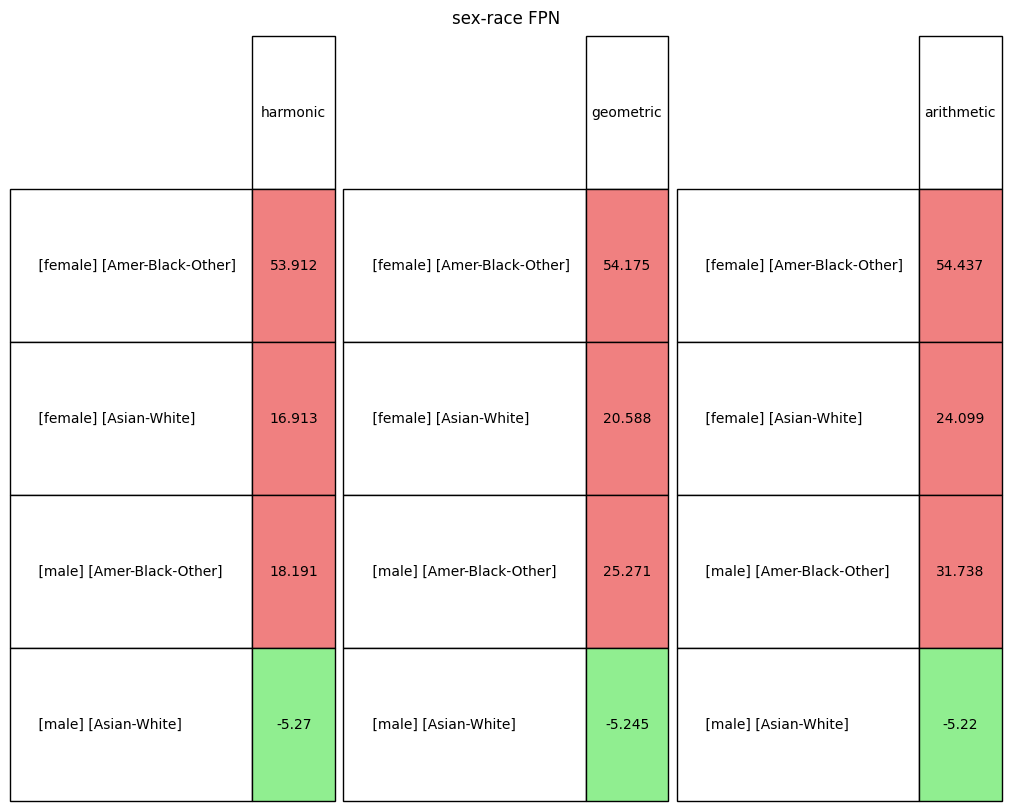

---

# Model 2: Fairness metrics and penalty after reweighting

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
# Takes a dictionary of weights with keys as lambda values andd values as weight arrays
def compute_penalties_after_reweighting(weights, fairness_metric = 'PPE', sensible_attribute = 'sex-race'):
  # Train Model 2 with weights and get predictions on test set

  # model_2 = RandomForestClassifier(random_state=1234).fit(
  #     X_train[sensible_attribute], 
  #     y_train[sensible_attribute], 
  #     sample_weight = weights_per_metric['ppe']  # Change this to use different weights
  # )
  # y_pred_model2_test = model_2.predict(X_test[sensible_attribute])

  import xgboost as xgb
  # Convert string combinations to numeric codes for BOTH train and val
  X_train_numeric = X_train[sensible_attribute].copy()
  X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes

  X_test_numeric = X_test[sensible_attribute].copy()
  X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes

  model_2 = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
  model_2.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
  y_pred_model2_test = model_2.predict(X_test_numeric)


  attrs = sensible_attribute.split('-') + [sensible_attribute]
  # attrs = sensible_attribute.split('-') + [sensible_attribute]

  fairness_metrics_model2 = {}
  count_groups_model2 = {}

  # Load FRESH dataframe for metric computation (has all original columns)
  df_fresh = pd.read_csv(dataset_path)

  for attribute in attributes:
    # Create a clean copy for this attribute
    df_attr = df_fresh.copy()
    
    # If combined attribute, create it
    if '-' in attribute:
      individual_attrs = attribute.split('-')
      df_attr[attribute] = reduce(
        lambda x, y: x.astype(str) + y.astype(str), 
        [df_attr[col] for col in individual_attrs]
      )
      df_attr = df_attr.drop(columns=individual_attrs)
    
    # Get sensible indexes for test set
    sensible_indexes = df_attr[attribute].loc[list(X_test[attribute].index)]
    
    # Compute confusion matrix
    cm_dict_individual = compute_cm_group(
      df_attr, attribute, sensible_indexes,
      y_pred_model2_test, y_test[attribute], X_test[attribute], target_variable_labels
    )

    # precision, recall, accuracy, f1_score = performance_metrics(y_test[sensible_attribute], y_pred_model2_test)
    # print(f"Performance after reweighting: Precision={precision:.4f}, Recall={recall:.4f}, Accuracy={accuracy:.4f}, F1={f1_score:.4f}")
    
    fairness_metrics_model2[attribute] = {}
    for m in fair_metrics:
      fairness_metrics_model2[attribute][m], count_groups_model2[attribute] = compute_fairness_metrics_and_counts(cm_dict_individual, m, attribute, mapping, dataset_path)
  
  harmonic, geometric, arithmetic  = compute_penalty_2(fairness_metrics_model2, df_fresh, 'sex', 'race', fairness_metric)

  return harmonic
  

You can also now specify sensitive attribute

In [33]:
weights_notsized = compute_weights_notsized(5.0, 'PPE', sensible_attribute=sensible_attribute)
compute_penalties_after_reweighting(weights_notsized, 'PPE')

Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878177, '11': 0.01}


{'00': 62.9040404040404,
 '01': 33.41433199923766,
 '10': -19.0147885241053,
 '11': -25.35630332701018}

In [34]:
weights_notsized = compute_weights_notsized(5.0, 'FPN', sensible_attribute=sensible_attribute)
compute_penalties_after_reweighting(weights_notsized, 'FPN')

Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540286}


{'00': 17.142857142857146,
 '01': 19.075970469159326,
 '10': 32.22626232334968,
 '11': -6.536536588530936}

In [35]:
penalties_ontest_after_reweighting = {}

for metric in fair_metrics:
    print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric, sensible_attribute=sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    print("\n")

FAIRNESS METRIC: FPN
Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540286}


FAIRNESS METRIC: PPE
Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878177, '11': 0.01}


FAIRNESS METRIC: GFA
Training samples: 22792, Unique weights per group: {'00': 3.739360910092617, '01': 2.3569453501362325, '10': 1.2978734586365022, '11': 0.08878820096219453}


FAIRNESS METRIC: PPA
Training samples: 22792, Unique weights per group: {'00': 0.9429369122257052, '01': 0.9839824271192945, '10': 0.8701277237148296, '11': 1.0039713368654584}


FAIRNESS METRIC: OAE
Training samples: 22792, Unique weights per group: {'00': 0.737203522346929, '01': 0.7944565597636348, '10': 0.9172541259111212, '11': 1.1285451768979153}


FAIRNESS METRIC: FPR
Training samples: 22792, Unique weights per group: {'00': 1.1633064516129032, '01': 1.034734396914445

Conclusions:

Group 00: Penalty reduced from 100 to 62 | 48

Group 01: Penalty INCREASED from 16.8 to 33 | 31

Group 10: Penalty DECREASED from 9.2 to -19.0 (PPE) and INCREASED from 9.2 to 11.4

Group 11: Penalty DECREASED from -6.5 to -25 | -26

## Debugging prints

### BASELINE

In [36]:
# Penalties calculated using the TEST set (Model 1, no weights)
penalties_ontest

{'FPN': {'00': 100.0,
  '01': 17.006033182503767,
  '10': 9.410569105691046,
  '11': -6.000826367141095},
 'PPE': {'00': 100.0,
  '01': 27.12264150943397,
  '10': -23.290915517850834,
  '11': -25.55645151548099},
 'GFA': {'00': 53.1068524970964,
  '01': 28.395988024839564,
  '10': 5.481681234889338,
  '11': -17.78382704756545},
 'PPA': {'00': -26.12403100775193,
  '01': -1.0301917584659357,
  '10': 5.279192789968656,
  '11': 0.1668435516152302},
 'OAE': {'00': -3.7920826812639117,
  '01': -3.7622630955450496,
  '10': 0.6328547807031162,
  '11': 2.007267175482164},
 'FPR': {'00': 100.0,
  '01': 1.8648018648018643,
  '10': -18.78329128118866,
  '11': -0.490911394785142},
 'FPA': {'00': 30.644753392475664,
  '01': 18.679317615487832,
  '10': -18.335208098987632,
  '11': -13.518887935054956},
 'EOP': {'00': -8.562924828057762,
  '01': -26.597392893638972,
  '10': -46.06820578928863,
  '11': 6.362090356013227},
 'FNP': {'00': 28.002527018794698,
  '01': 12.95594335108013,
  '10': -27.559642

In [37]:
# Get baseline penalties on test set, with only the harmonic penalties
penalties_ontest_xd = {m: penalties_ontest[m] for m in fair_metrics}

In [38]:
penalties_ontest.keys()

dict_keys(['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP'])

---

In [39]:
# list(penalties_ontest[fair_metrics[0]][0].keys())
list(penalties_ontest[fair_metrics[0]].keys())

['00', '01', '10', '11']

# Plots

## Penalty before and after reweighting

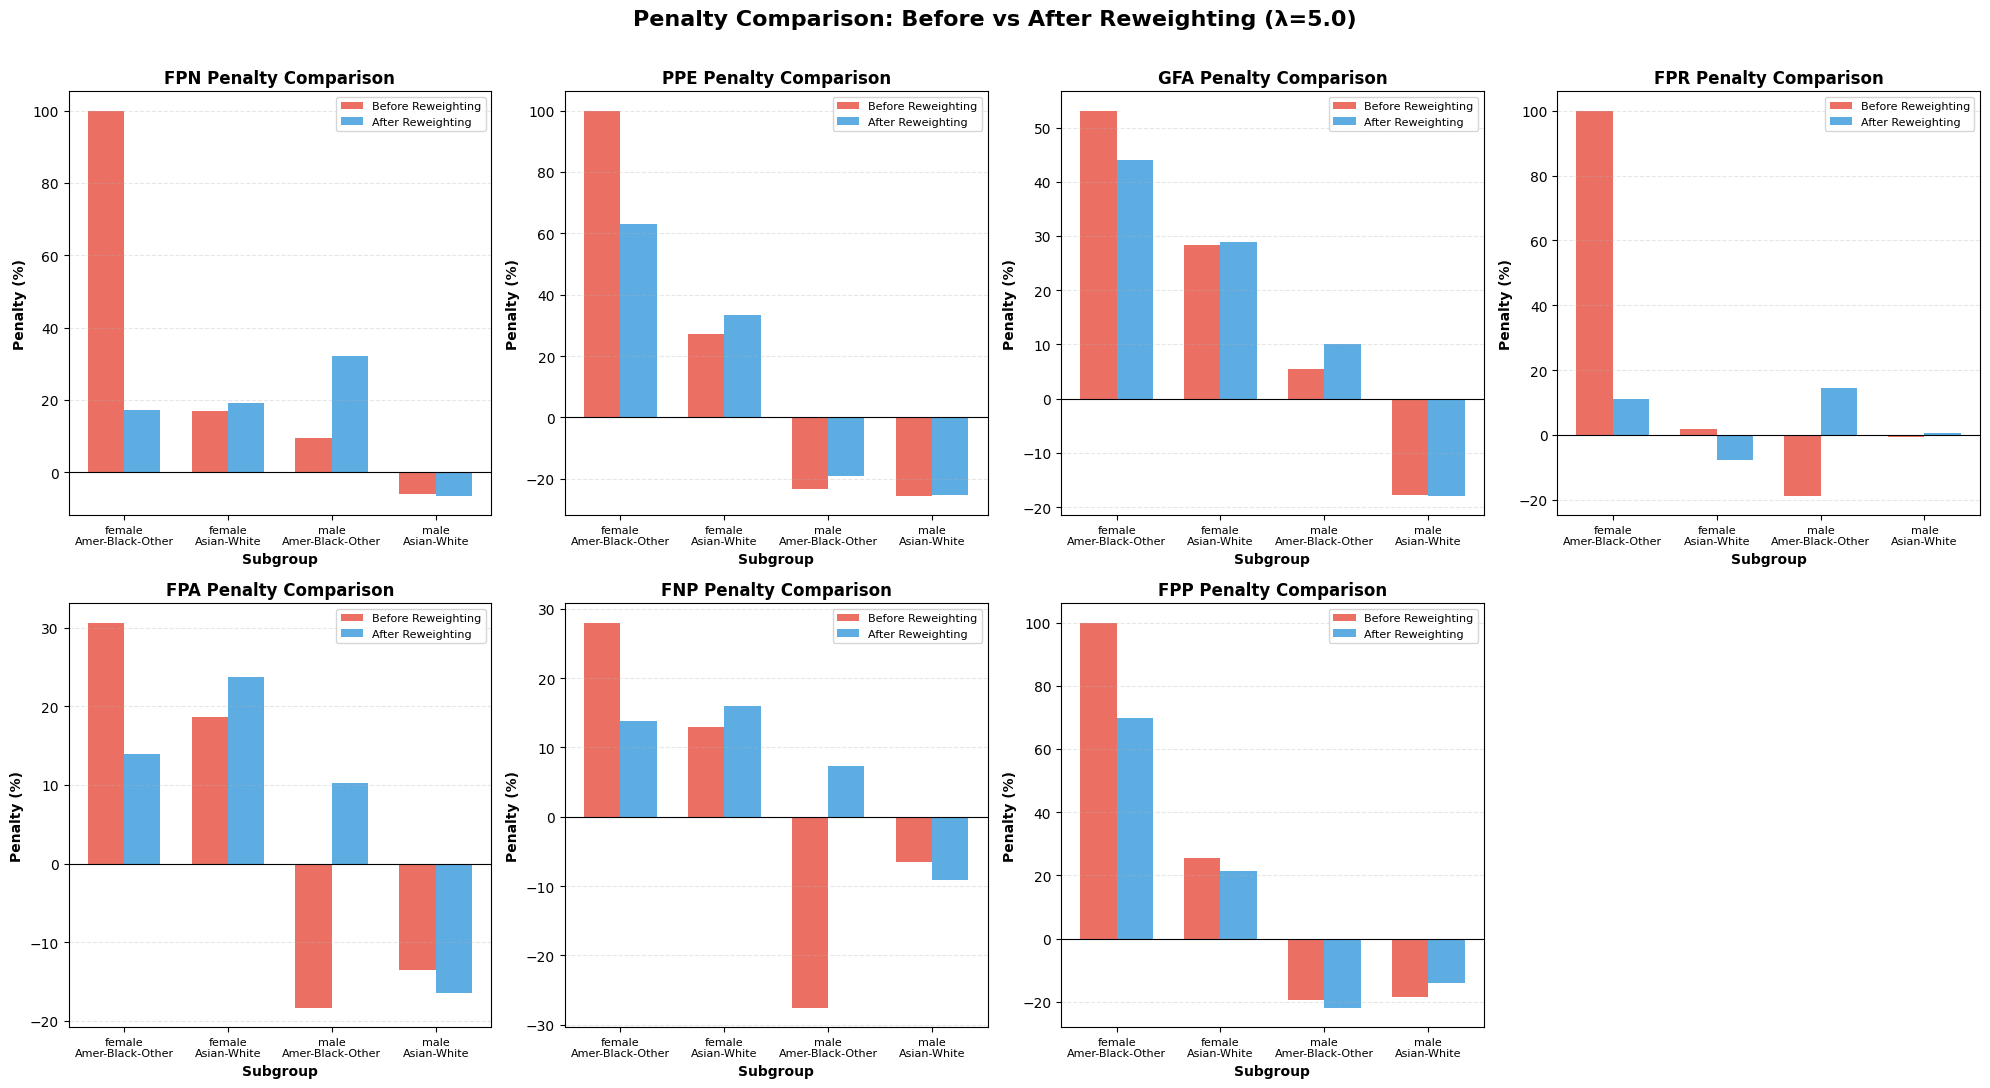

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting):
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels using mapping
        decoded_labels = []
        for group in subgroups:
            sex_code = group[0]
            race_code = group[1]
            sex_label = mapping['sex'][int(sex_code)]
            race_label = mapping['race'][int(race_code)]
            decoded_labels.append(f"{sex_label}\n{race_label}")
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle('Penalty Comparison: Before vs After Reweighting (λ=5.0)', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

fair_metrics=['FPN', 'PPE', 'GFA', 'FPR', 'FPA', 'FNP', 'FPP']
plot_penalty_comparison_all(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting)

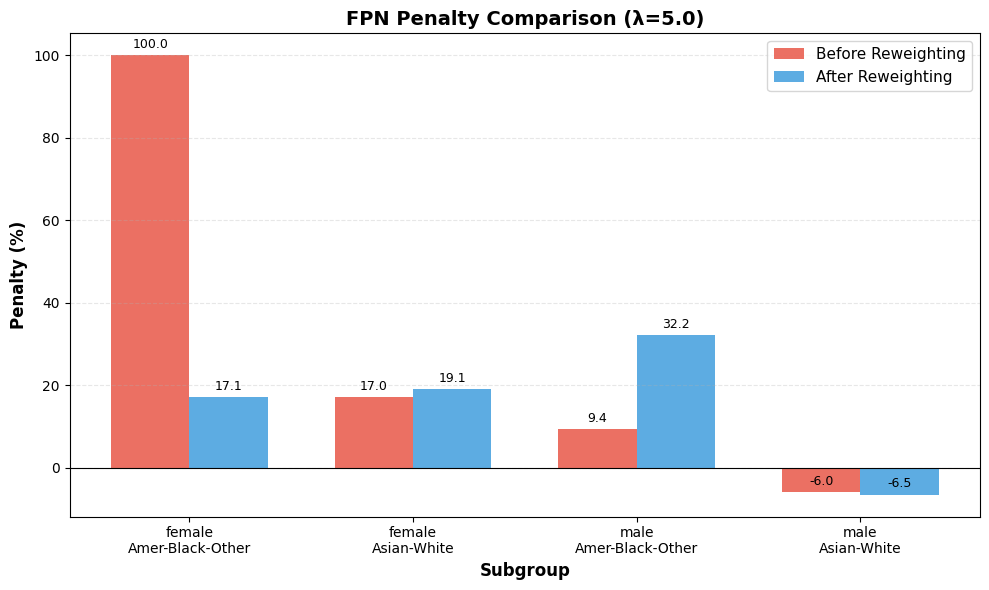


FPN - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 17.14 (Δ = -82.86)
  female-Asian-White: 17.01 → 19.08 (Δ = +2.07)
  male-Amer-Black-Other: 9.41 → 32.23 (Δ = +22.82)
  male-Asian-White: -6.00 → -6.54 (Δ = -0.54)
------------------------------------------------------------


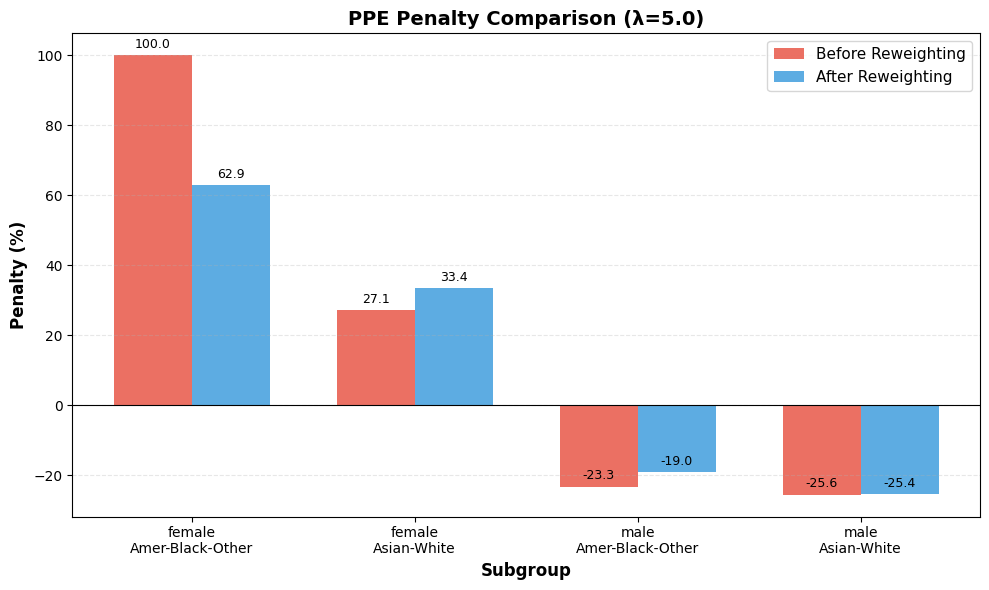


PPE - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 62.90 (Δ = -37.10)
  female-Asian-White: 27.12 → 33.41 (Δ = +6.29)
  male-Amer-Black-Other: -23.29 → -19.01 (Δ = +4.28)
  male-Asian-White: -25.56 → -25.36 (Δ = +0.20)
------------------------------------------------------------


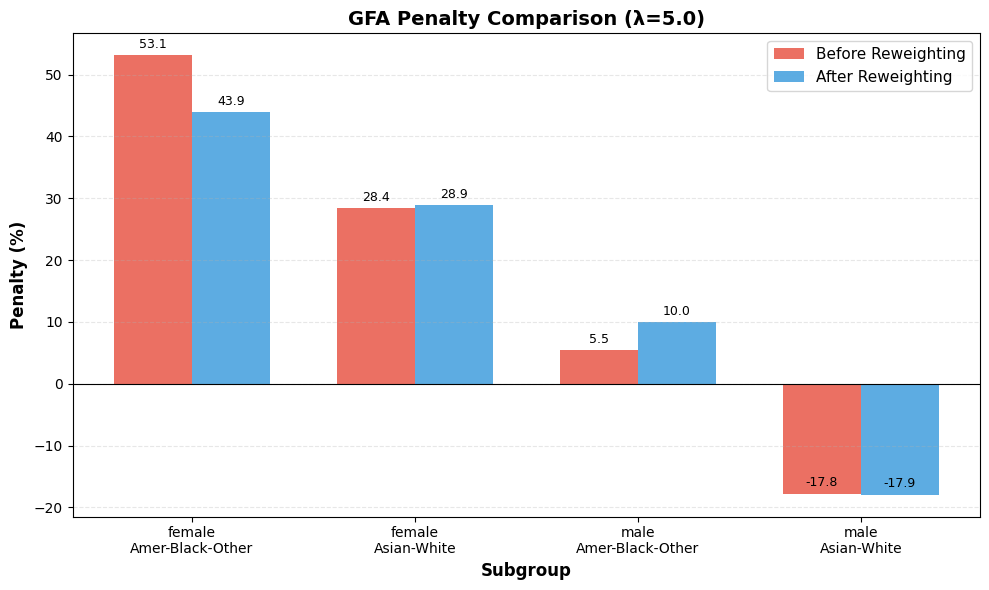


GFA - Penalty Changes:
  female-Amer-Black-Other: 53.11 → 43.94 (Δ = -9.16)
  female-Asian-White: 28.40 → 28.88 (Δ = +0.48)
  male-Amer-Black-Other: 5.48 → 10.01 (Δ = +4.53)
  male-Asian-White: -17.78 → -17.93 (Δ = -0.15)
------------------------------------------------------------


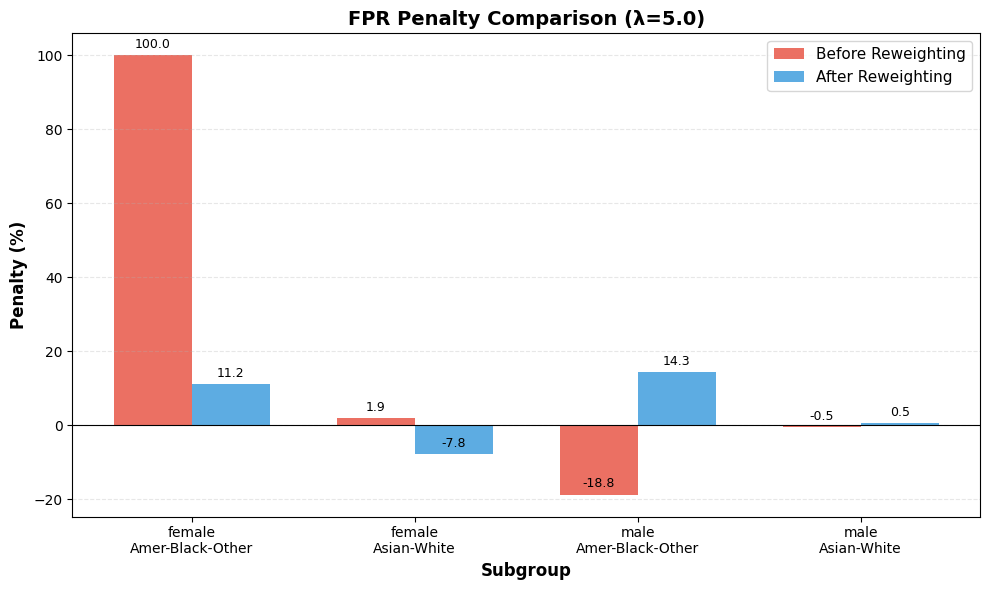


FPR - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 11.16 (Δ = -88.84)
  female-Asian-White: 1.86 → -7.79 (Δ = -9.66)
  male-Amer-Black-Other: -18.78 → 14.34 (Δ = +33.13)
  male-Asian-White: -0.49 → 0.53 (Δ = +1.02)
------------------------------------------------------------


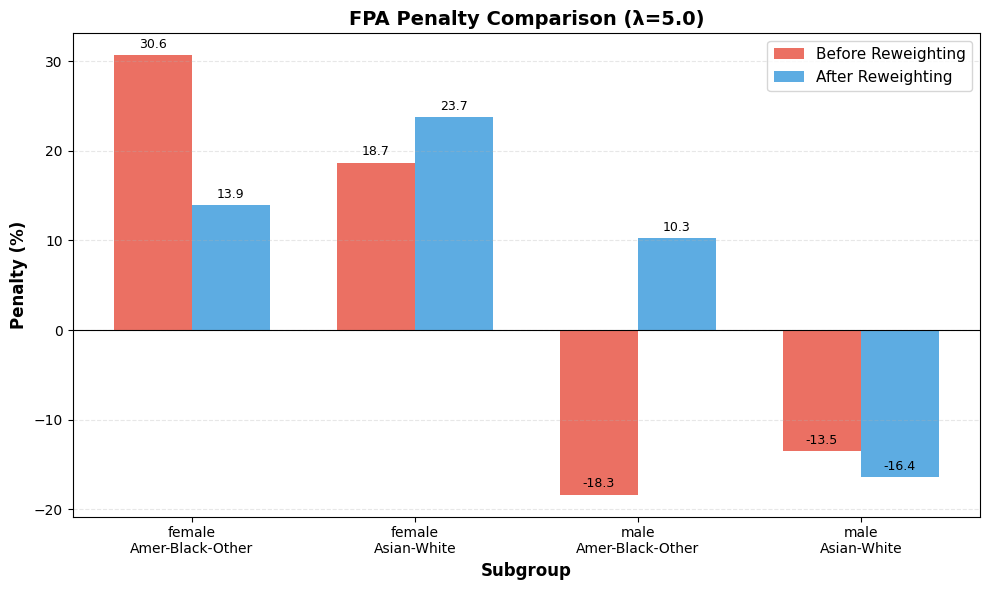


FPA - Penalty Changes:
  female-Amer-Black-Other: 30.64 → 13.91 (Δ = -16.73)
  female-Asian-White: 18.68 → 23.72 (Δ = +5.04)
  male-Amer-Black-Other: -18.34 → 10.26 (Δ = +28.59)
  male-Asian-White: -13.52 → -16.40 (Δ = -2.89)
------------------------------------------------------------


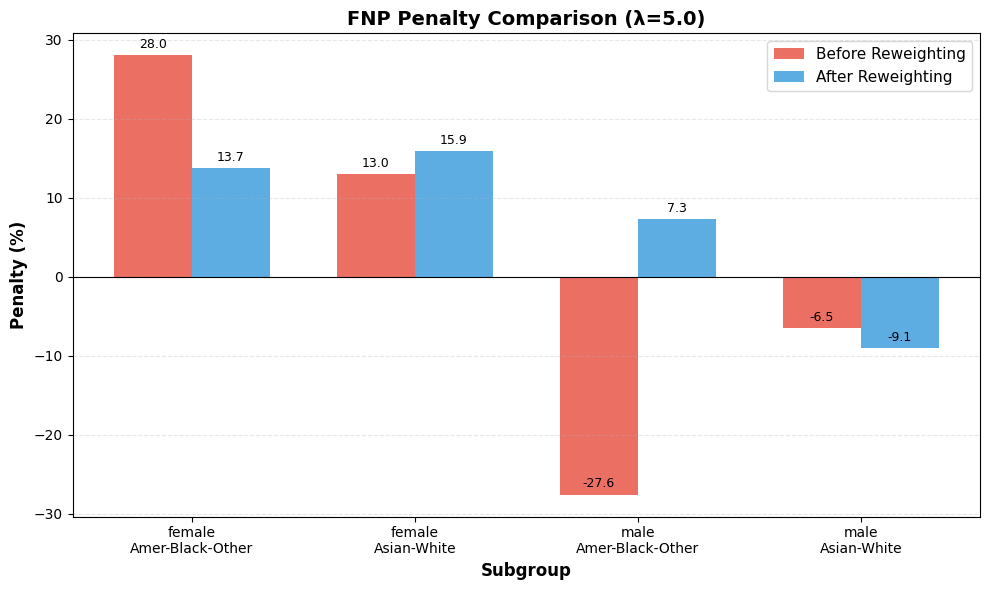


FNP - Penalty Changes:
  female-Amer-Black-Other: 28.00 → 13.75 (Δ = -14.25)
  female-Asian-White: 12.96 → 15.93 (Δ = +2.98)
  male-Amer-Black-Other: -27.56 → 7.34 (Δ = +34.90)
  male-Asian-White: -6.54 → -9.06 (Δ = -2.52)
------------------------------------------------------------


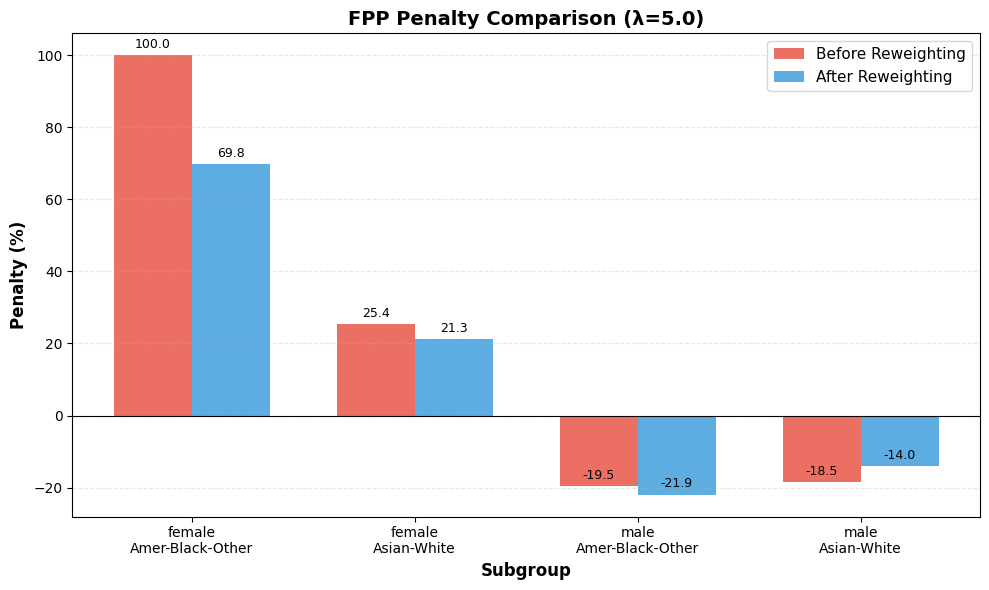


FPP - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 69.76 (Δ = -30.24)
  female-Asian-White: 25.35 → 21.33 (Δ = -4.03)
  male-Amer-Black-Other: -19.52 → -21.94 (Δ = -2.42)
  male-Asian-White: -18.46 → -14.05 (Δ = +4.41)
------------------------------------------------------------


In [41]:
# Individual plots for each metric (larger view for detailed inspection)
subgroups = list(penalties_ontest[fair_metrics[0]].keys())

for metric in fair_metrics:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Extract penalties before and after for this metric
    penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
    penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
    
    # Set up bar positions
    x = np.arange(len(subgroups))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
    bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    
    # Decode subgroup labels using mapping
    decoded_labels = []
    for group in subgroups:
        sex_code = group[0]
        race_code = group[1]
        sex_label = mapping['sex'][int(sex_code)]
        race_label = mapping['race'][int(race_code)]
        decoded_labels.append(f"{sex_label}\n{race_label}")
    
    # Customize plot
    ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
    ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Penalty Comparison (λ=5.0)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(decoded_labels, fontsize=10)
    ax.legend(fontsize=11, loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()
    print(f"\n{metric} - Penalty Changes:")
    for i, group in enumerate(subgroups):
        before = penalties_before[i]
        after = penalties_after[i]
        change = after - before
        print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
    print("-" * 60)

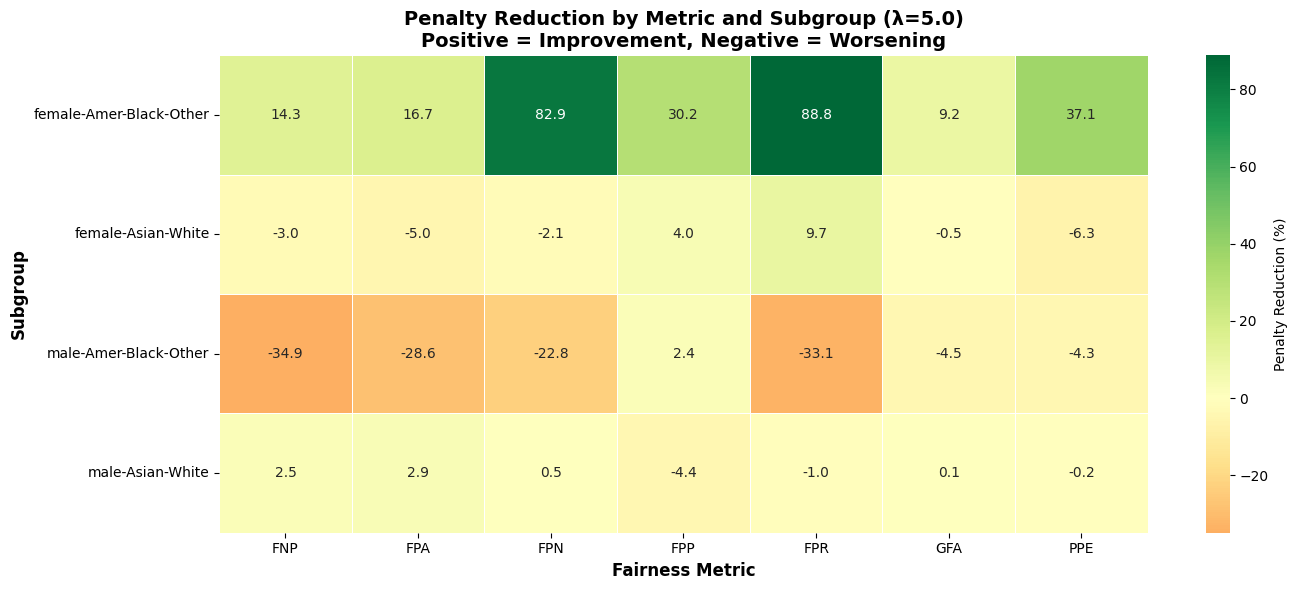


Summary Statistics:
        Before  After  Reduction
Metric                          
FNP       1.72   6.99      -5.28
FPA       4.37   7.87      -3.50
FPN      30.10  15.48      14.63
FPP      21.84  13.77       8.07
FPR      20.65   4.56      16.09
GFA      17.30  16.23       1.07
PPE      19.57  12.99       6.58


In [42]:
# Alternative visualization: Summary heatmap showing penalty reduction
import pandas as pd
import seaborn as sns

# Create a summary dataframe
summary_data = []
for metric in fair_metrics:
    for group in subgroups:
        penalty_before = penalties_ontest[metric].get(group, 0)
        penalty_after = penalties_ontest_after_reweighting[metric].get(group, 0)
        reduction = penalty_before - penalty_after
        
        # Decode group
        sex_code = group[0]
        race_code = group[1]
        sex_label = mapping['sex'][int(sex_code)]
        race_label = mapping['race'][int(race_code)]
        group_label = f"{sex_label}-{race_label}"
        
        summary_data.append({
            'Metric': metric,
            'Subgroup': group_label,
            'Before': penalty_before,
            'After': penalty_after,
            'Reduction': reduction
        })

df_summary = pd.DataFrame(summary_data)

# Create pivot table for heatmap
pivot_reduction = df_summary.pivot(index='Subgroup', columns='Metric', values='Reduction')

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_reduction, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Penalty Reduction (%)'}, linewidths=0.5)
plt.title('Penalty Reduction by Metric and Subgroup (λ=5.0)\nPositive = Improvement, Negative = Worsening', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fairness Metric', fontsize=12, fontweight='bold')
plt.ylabel('Subgroup', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print(df_summary.groupby('Metric')[['Before', 'After', 'Reduction']].mean().round(2))

---

---

# Distribution Analysis: Identifying Subgroups with Sufficient Sample Size

Tp understand:
1. **Which subgroups have enough samples** for stable penalty calculations
2. **How distributions differ** between validation and test sets (causing penalty instability)
3. **Subgroup balance** within positive/negative labels

## 1. Overall Dataset Distribution by Subgroup

First, let's look at the ENTIRE dataset to see the natural distribution of each 2-cardinality subgroup.

In [43]:
# Define all 2-cardinality subgroup combinations
two_attr_combinations = [
    'age-sex', 'age-race', 'age-edu', 
    'sex-race', 'sex-edu', 'race-edu'
]

# Load fresh dataset
df_full = pd.read_csv(dataset_path)

print("="*80)
print("OVERALL DATASET DISTRIBUTION (All 2-Cardinality Subgroups)")
print("="*80)

overall_distribution = {}

for combo in two_attr_combinations:
    attrs = combo.split('-')
    df_temp = df_full.copy()
    
    # Create combined attribute column
    df_temp[combo] = reduce(lambda x, y: x.astype(str) + y.astype(str), 
                            [df_temp[col] for col in attrs])
    
    # Count total samples per subgroup
    total_counts = df_temp[combo].value_counts().sort_index()
    
    # Count by label (income=0 vs income=1)
    label_0_counts = df_temp[df_temp[target_variable] == 0][combo].value_counts().sort_index()
    label_1_counts = df_temp[df_temp[target_variable] == 1][combo].value_counts().sort_index()
    
    overall_distribution[combo] = {
        'total': total_counts,
        'income=0': label_0_counts,
        'income=1': label_1_counts
    }
    
    print(f"\n{combo.upper()}:")
    print("-" * 60)
    for subgroup in sorted(total_counts.index):
        total = total_counts.get(subgroup, 0)
        neg = label_0_counts.get(subgroup, 0)
        pos = label_1_counts.get(subgroup, 0)
        balance_ratio = pos / neg if neg > 0 else 0
        
        # Decode subgroup
        decoded = ' + '.join([mapping[attrs[i]][int(subgroup[i])] for i in range(len(attrs))])
        
        print(f"  {subgroup} ({decoded:30s}): Total={total:5d} | income=0: {neg:5d} | income=1: {pos:5d} | Ratio: {balance_ratio:.3f}")

print("\n" + "="*80)

OVERALL DATASET DISTRIBUTION (All 2-Cardinality Subgroups)

AGE-SEX:
------------------------------------------------------------
  00 (young + female                ): Total= 5554 | income=0:  5216 | income=1:   338 | Ratio: 0.065
  01 (young + male                  ): Total= 9371 | income=0:  8004 | income=1:  1367 | Ratio: 0.171
  10 (adult + female                ): Total= 5217 | income=0:  4376 | income=1:   841 | Ratio: 0.192
  11 (adult + male                  ): Total=12419 | income=0:  7124 | income=1:  5295 | Ratio: 0.743

AGE-RACE:
------------------------------------------------------------
  00 (young + Amer-Black-Other      ): Total= 1825 | income=0:  1726 | income=1:    99 | Ratio: 0.057
  01 (young + Asian-White           ): Total=13100 | income=0: 11494 | income=1:  1606 | Ratio: 0.140
  10 (adult + Amer-Black-Other      ): Total= 1881 | income=0:  1532 | income=1:   349 | Ratio: 0.228
  11 (adult + Asian-White           ): Total=15755 | income=0:  9968 | income=1:  57

## 2. Validation vs Test Set Distribution Comparison

Now compare how each subgroup is distributed across validation and test sets. **Large differences = unstable penalties**.

In [44]:
print("="*80)
print("VALIDATION vs TEST DISTRIBUTION COMPARISON")
print("="*80)

distribution_comparison = {}

for combo in two_attr_combinations:
    attrs = combo.split('-')
    
    # Get validation and test data for this combination
    val_data = X_val[combo].copy()
    val_data[target_variable] = y_val[combo]
    
    test_data = X_test[combo].copy()
    test_data[target_variable] = y_test[combo]
    
    # Count distributions
    val_total = val_data[combo].value_counts().sort_index()
    test_total = test_data[combo].value_counts().sort_index()
    
    val_neg = val_data[val_data[target_variable] == 0][combo].value_counts().sort_index()
    val_pos = val_data[val_data[target_variable] == 1][combo].value_counts().sort_index()
    
    test_neg = test_data[test_data[target_variable] == 0][combo].value_counts().sort_index()
    test_pos = test_data[test_data[target_variable] == 1][combo].value_counts().sort_index()
    
    distribution_comparison[combo] = {
        'val_total': val_total,
        'test_total': test_total,
        'val_neg': val_neg,
        'val_pos': val_pos,
        'test_neg': test_neg,
        'test_pos': test_pos
    }
    
    print(f"\n{combo.upper()}:")
    print("-" * 80)
    print(f"{'Subgroup':12s} | {'Val Total':>10s} | {'Test Total':>10s} | {'Val(0/1)':>15s} | {'Test(0/1)':>15s} | {'Δ%':>8s}")
    print("-" * 80)
    
    all_subgroups = sorted(set(val_total.index) | set(test_total.index))
    
    for subgroup in all_subgroups:
        v_tot = val_total.get(subgroup, 0)
        t_tot = test_total.get(subgroup, 0)
        v_neg = val_neg.get(subgroup, 0)
        v_pos = val_pos.get(subgroup, 0)
        t_neg = test_neg.get(subgroup, 0)
        t_pos = test_pos.get(subgroup, 0)
        
        # Calculate percentage difference
        pct_diff = ((t_tot - v_tot) / v_tot * 100) if v_tot > 0 else 0
        
        # Decode subgroup
        decoded = '-'.join([mapping[attrs[i]][int(subgroup[i])] for i in range(len(attrs))])
        
        print(f"{subgroup} ({decoded:20s}) | {v_tot:10d} | {t_tot:10d} | {v_neg:5d}/{v_pos:5d} | {t_neg:5d}/{t_pos:5d} | {pct_diff:+7.1f}%")

print("\n" + "="*80)

VALIDATION vs TEST DISTRIBUTION COMPARISON


KeyError: 'age-sex'

## 3. Confusion Matrix Analysis: Identifying Sparse Cells

Check which subgroups have **dangerously low** FP or FN counts (leading to unstable fairness metrics).

In [ ]:
print("="*80)
print("CONFUSION MATRIX ANALYSIS: Identifying Sparse Cells")
print("="*80)
print("\nConfusion Matrix Structure: [[TN, FP], [FN, TP]]")
print("⚠️  Warning: FP or FN < 5 can lead to unstable fairness metrics\n")

# Minimum threshold for stability
MIN_THRESHOLD = 5

cm_analysis = {}

for combo in two_attr_combinations:
    attrs = combo.split('-')
    
    # We need to compute confusion matrices for this combination on BOTH val and test
    df_temp = pd.read_csv(dataset_path)
    df_temp[combo] = reduce(lambda x, y: x.astype(str) + y.astype(str), 
                            [df_temp[col] for col in attrs])
    
    # For validation set
    sensible_indexes_val = df_temp[combo].loc[list(X_val[combo].index)]
    cm_dict_val = compute_cm_group(
        df_temp, combo, sensible_indexes_val,
        y_pred[combo], y_val[combo], X_val[combo], target_variable_labels
    )
    
    # For test set - need predictions from baseline model
    sensible_indexes_test = df_temp[combo].loc[list(X_test[combo].index)]
    
    # Use the baseline model for this combo (if it exists, otherwise use sex-race model)
    if combo in model_baseline:
        test_predictions = model_baseline[combo].predict(X_test[combo])
    else:
        # Need to train a model for this combo
        import xgboost as xgb
        X_train_numeric = X_train[combo].copy()
        X_train_numeric[combo] = X_train_numeric[combo].astype('category').cat.codes
        X_test_numeric = X_test[combo].copy()
        X_test_numeric[combo] = X_test_numeric[combo].astype('category').cat.codes
        temp_model = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        temp_model.fit(X_train_numeric, y_train[combo])
        test_predictions = temp_model.predict(X_test_numeric)
    
    cm_dict_test = compute_cm_group(
        df_temp, combo, sensible_indexes_test,
        test_predictions, y_test[combo], X_test[combo], target_variable_labels
    )
    
    cm_analysis[combo] = {
        'val': cm_dict_val,
        'test': cm_dict_test
    }
    
    print(f"\n{combo.upper()}:")
    print("-" * 80)
    
    all_subgroups = sorted(set(cm_dict_val.keys()) | set(cm_dict_test.keys()))
    
    for subgroup in all_subgroups:
        decoded = '-'.join([mapping[attrs[i]][int(subgroup[i])] for i in range(len(attrs))])
        
        # Validation CM
        if subgroup in cm_dict_val:
            cm_val = cm_dict_val[subgroup]
            tn_val, fp_val = cm_val[0]
            fn_val, tp_val = cm_val[1]
        else:
            tn_val = fp_val = fn_val = tp_val = 0
        
        # Test CM
        if subgroup in cm_dict_test:
            cm_test = cm_dict_test[subgroup]
            tn_test, fp_test = cm_test[0]
            fn_test, tp_test = cm_test[1]
        else:
            tn_test = fp_test = fn_test = tp_test = 0
        
        # Identify issues
        issues = []
        if fp_val < MIN_THRESHOLD:
            issues.append(f"Val FP={fp_val}")
        if fn_val < MIN_THRESHOLD:
            issues.append(f"Val FN={fn_val}")
        if fp_test < MIN_THRESHOLD:
            issues.append(f"Test FP={fp_test}")
        if fn_test < MIN_THRESHOLD:
            issues.append(f"Test FN={fn_test}")
        
        # Calculate FP and FN differences between val and test
        fp_diff = fp_test - fp_val
        fn_diff = fn_test - fn_val
        
        warning = "⚠️  " if issues else "   "
        
        print(f"{warning}{subgroup} ({decoded:20s})")
        print(f"     Validation:  TN={tn_val:4d}, FP={fp_val:4d}, FN={fn_val:4d}, TP={tp_val:4d}")
        print(f"     Test:        TN={tn_test:4d}, FP={fp_test:4d}, FN={fn_test:4d}, TP={tp_test:4d}")
        print(f"     Δ (Test-Val):        FP={fp_diff:+4d},        FN={fn_diff:+4d}")
        
        if issues:
            print(f"     🔴 ISSUES: {', '.join(issues)}")
        print()

print("="*80)

CONFUSION MATRIX ANALYSIS: Identifying Sparse Cells

Confusion Matrix Structure: [[TN, FP], [FN, TP]]
⚠️  Warning: FP or FN < 5 can lead to unstable fairness metrics



KeyError: 'age-sex'

## 4. Visual Comparison: Validation vs Test Distribution

Visualize the distribution differences to quickly identify problematic subgroups.

KeyError: 'age-sex'

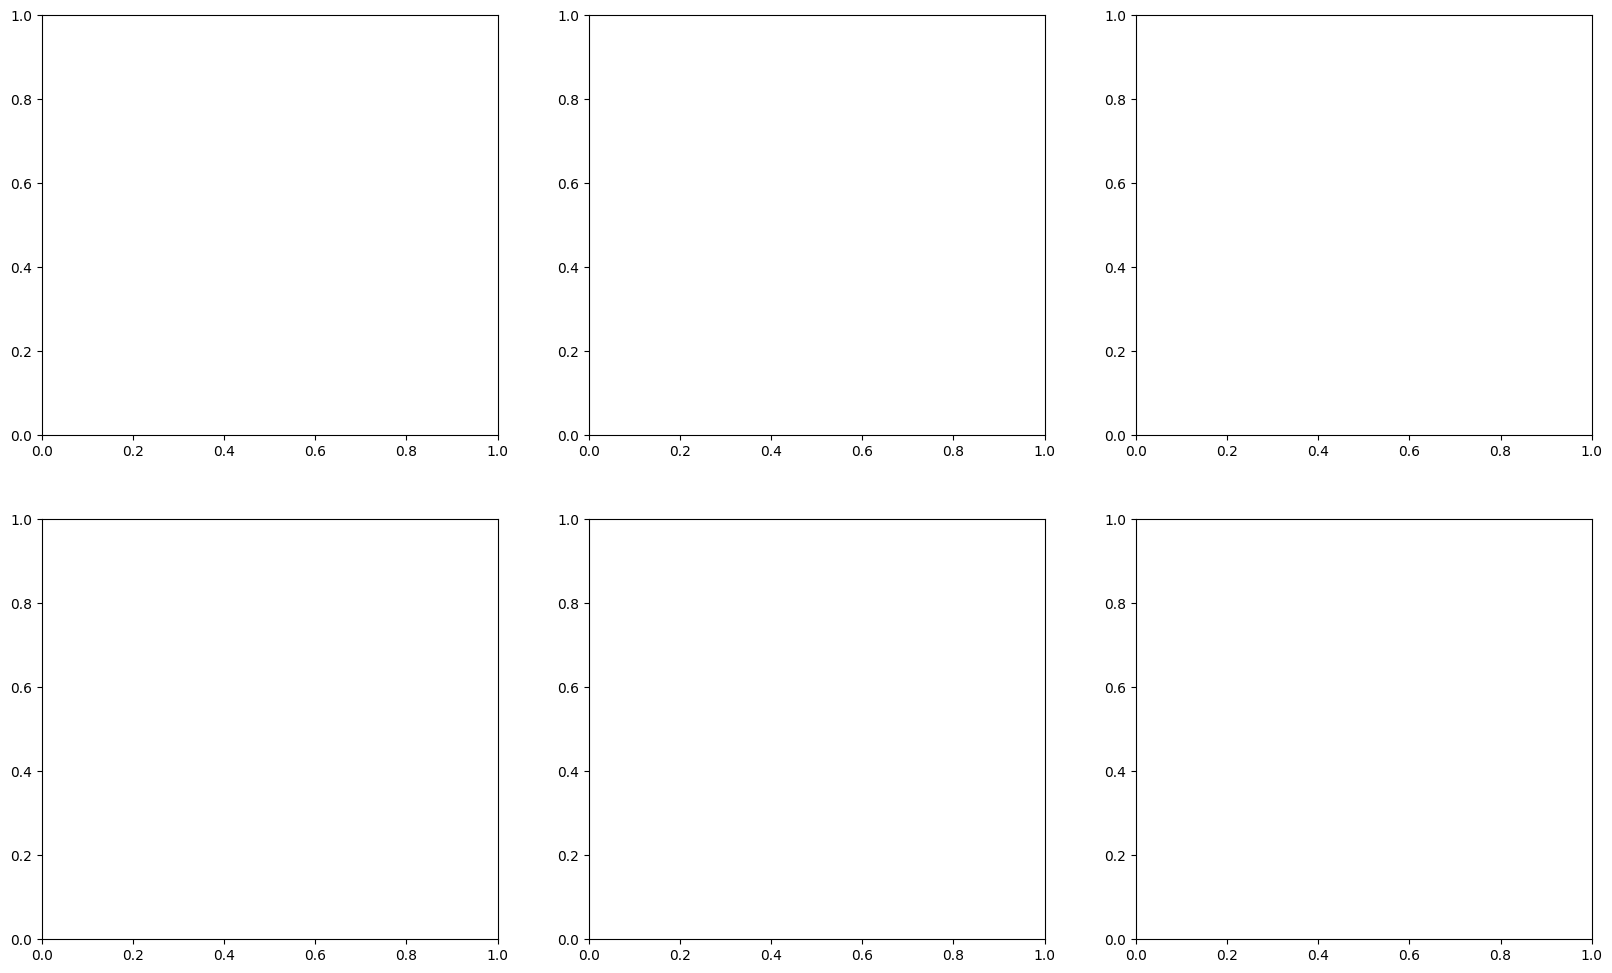

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, combo in enumerate(two_attr_combinations):
    ax = axes[idx]
    attrs = combo.split('-')
    
    val_total = distribution_comparison[combo]['val_total']
    test_total = distribution_comparison[combo]['test_total']
    
    all_subgroups = sorted(set(val_total.index) | set(test_total.index))
    
    val_counts = [val_total.get(sg, 0) for sg in all_subgroups]
    test_counts = [test_total.get(sg, 0) for sg in all_subgroups]
    
    # Decode labels
    decoded_labels = []
    for sg in all_subgroups:
        decoded = '\n'.join([mapping[attrs[i]][int(sg[i])] for i in range(len(attrs))])
        decoded_labels.append(f"{sg}\n{decoded}")
    
    x = np.arange(len(all_subgroups))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, val_counts, width, label='Validation', alpha=0.8, color='#3498db')
    bars2 = ax.bar(x + width/2, test_counts, width, label='Test', alpha=0.8, color='#e74c3c')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
    ax.set_ylabel('Sample Count', fontsize=10, fontweight='bold')
    ax.set_title(f'{combo.upper()}: Val vs Test Distribution', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(decoded_labels, fontsize=7)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.suptitle('Validation vs Test Set Distribution Comparison', 
            fontsize=16, fontweight='bold', y=1.03)
plt.show()

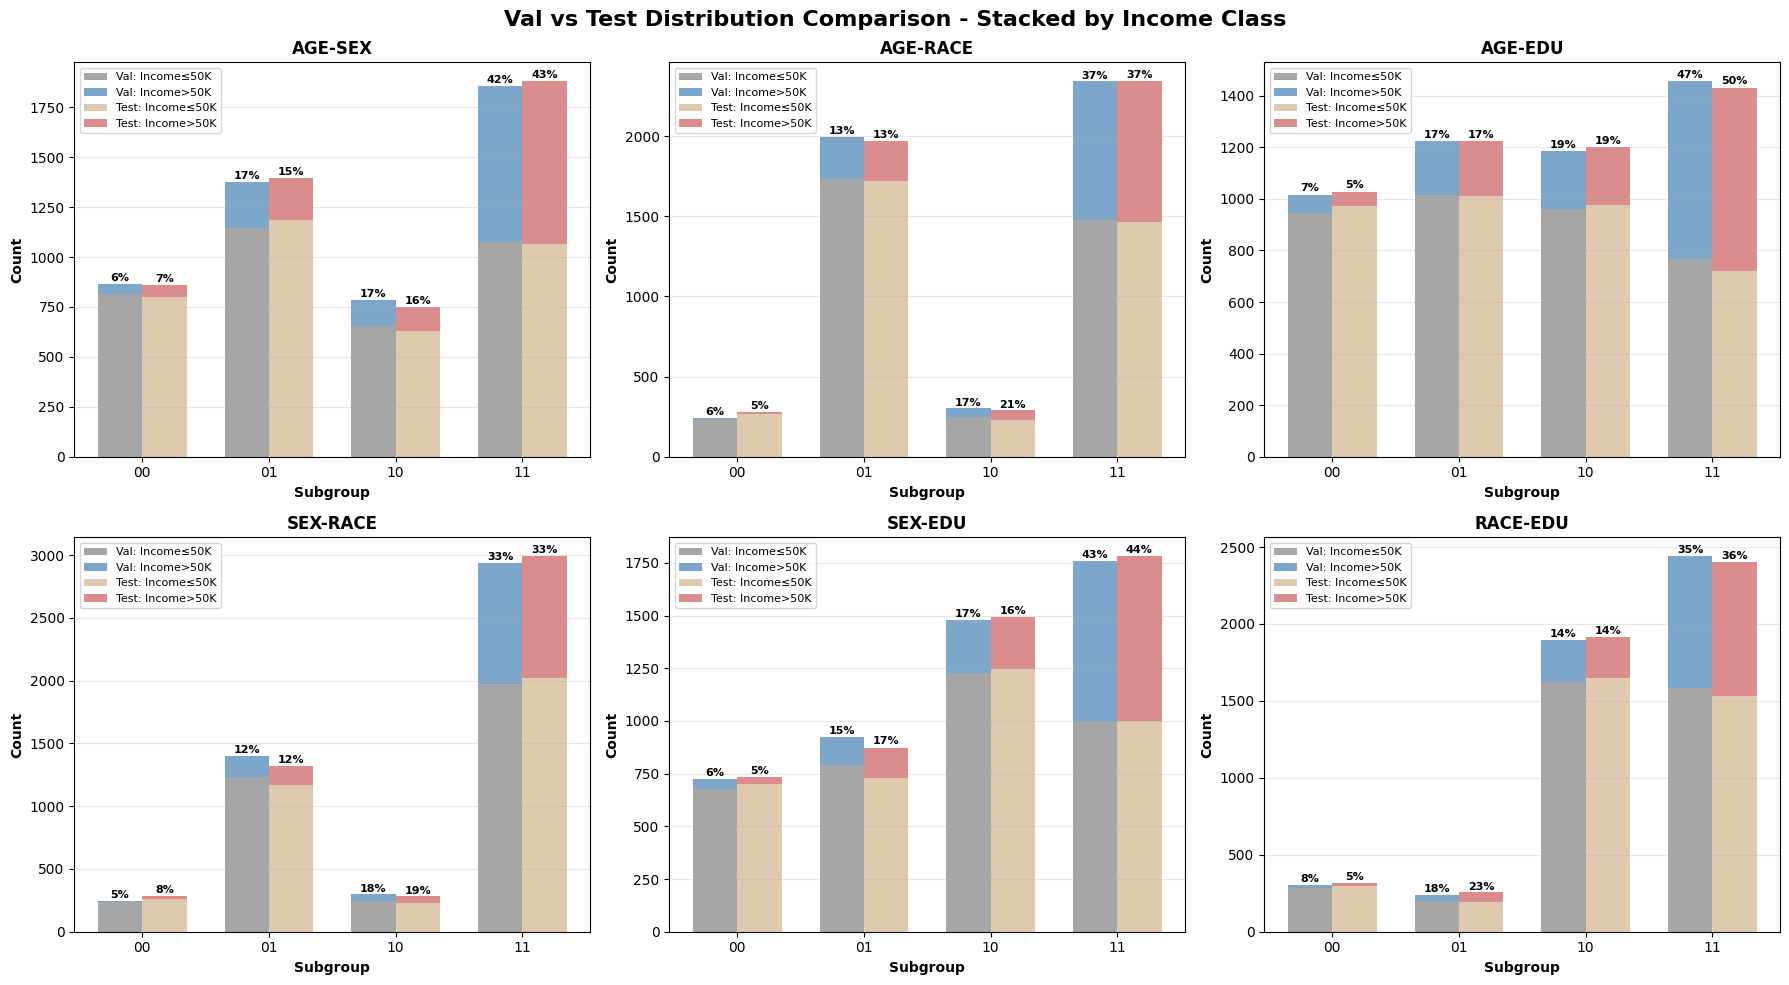

In [ ]:
# Create visualization with stacked bars showing class distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Val vs Test Distribution Comparison - Stacked by Income Class', fontsize=16, fontweight='bold')

for idx, combo in enumerate(two_attr_combinations):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Get data for this combo
    v_tot = distribution_comparison[combo]['val_total']
    t_tot = distribution_comparison[combo]['test_total']
    v_neg = distribution_comparison[combo]['val_neg']  # income=0
    v_pos = distribution_comparison[combo]['val_pos']  # income=1
    t_neg = distribution_comparison[combo]['test_neg']  # income=0
    t_pos = distribution_comparison[combo]['test_pos']  # income=1
    
    # Decode attribute labels
    attrs = combo.split('-')
    decoded_labels = []
    for i, attr in enumerate(attrs):
        for code, labels in mapping[protected_attributes[i]].items():
            if attr == protected_attributes[i]:
                decoded_labels.append(labels)
                break
    
    # Get subgroup labels
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    width = 0.35
    
    # Create stacked bars
    # Validation: bottom (gray) = income≤50K, top (blue) = income>50K
    bars1_bottom = ax.bar(x - width/2, v_neg, width, label='Val: Income≤50K', color='gray', alpha=0.7)
    bars1_top = ax.bar(x - width/2, v_pos, width, bottom=v_neg, label='Val: Income>50K', color='steelblue', alpha=0.7)
    
    # Test: bottom (tan) = income≤50K, top (red) = income>50K
    bars2_bottom = ax.bar(x + width/2, t_neg, width, label='Test: Income≤50K', color='tan', alpha=0.7)
    bars2_top = ax.bar(x + width/2, t_pos, width, bottom=t_neg, label='Test: Income>50K', color='indianred', alpha=0.7)
    
    # Add percentage labels for income>50K
    for i, (val_p, test_p, val_t, test_t) in enumerate(zip(v_pos, t_pos, v_tot, t_tot)):
        # Validation percentage
        if val_t > 0:
            val_pct = (val_p / val_t) * 100
            ax.text(i - width/2, val_t + 5, f'{val_pct:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
        # Test percentage
        if test_t > 0:
            test_pct = (test_p / test_t) * 100
            ax.text(i + width/2, test_t + 5, f'{test_pct:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_xlabel('Subgroup', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(f'{combo.upper()}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
cm_dict

{'01': array([[1144,   22],
        [  80,   77]]),
 '00': array([[264,   0],
        [ 14,   9]]),
 '11': array([[1782,  237],
        [ 292,  681]]),
 '10': array([[222,   8],
        [ 32,  21]])}

## 5. Label Balance Analysis Within Subgroups

Check if each subgroup has balanced positive/negative samples (important for fairness).

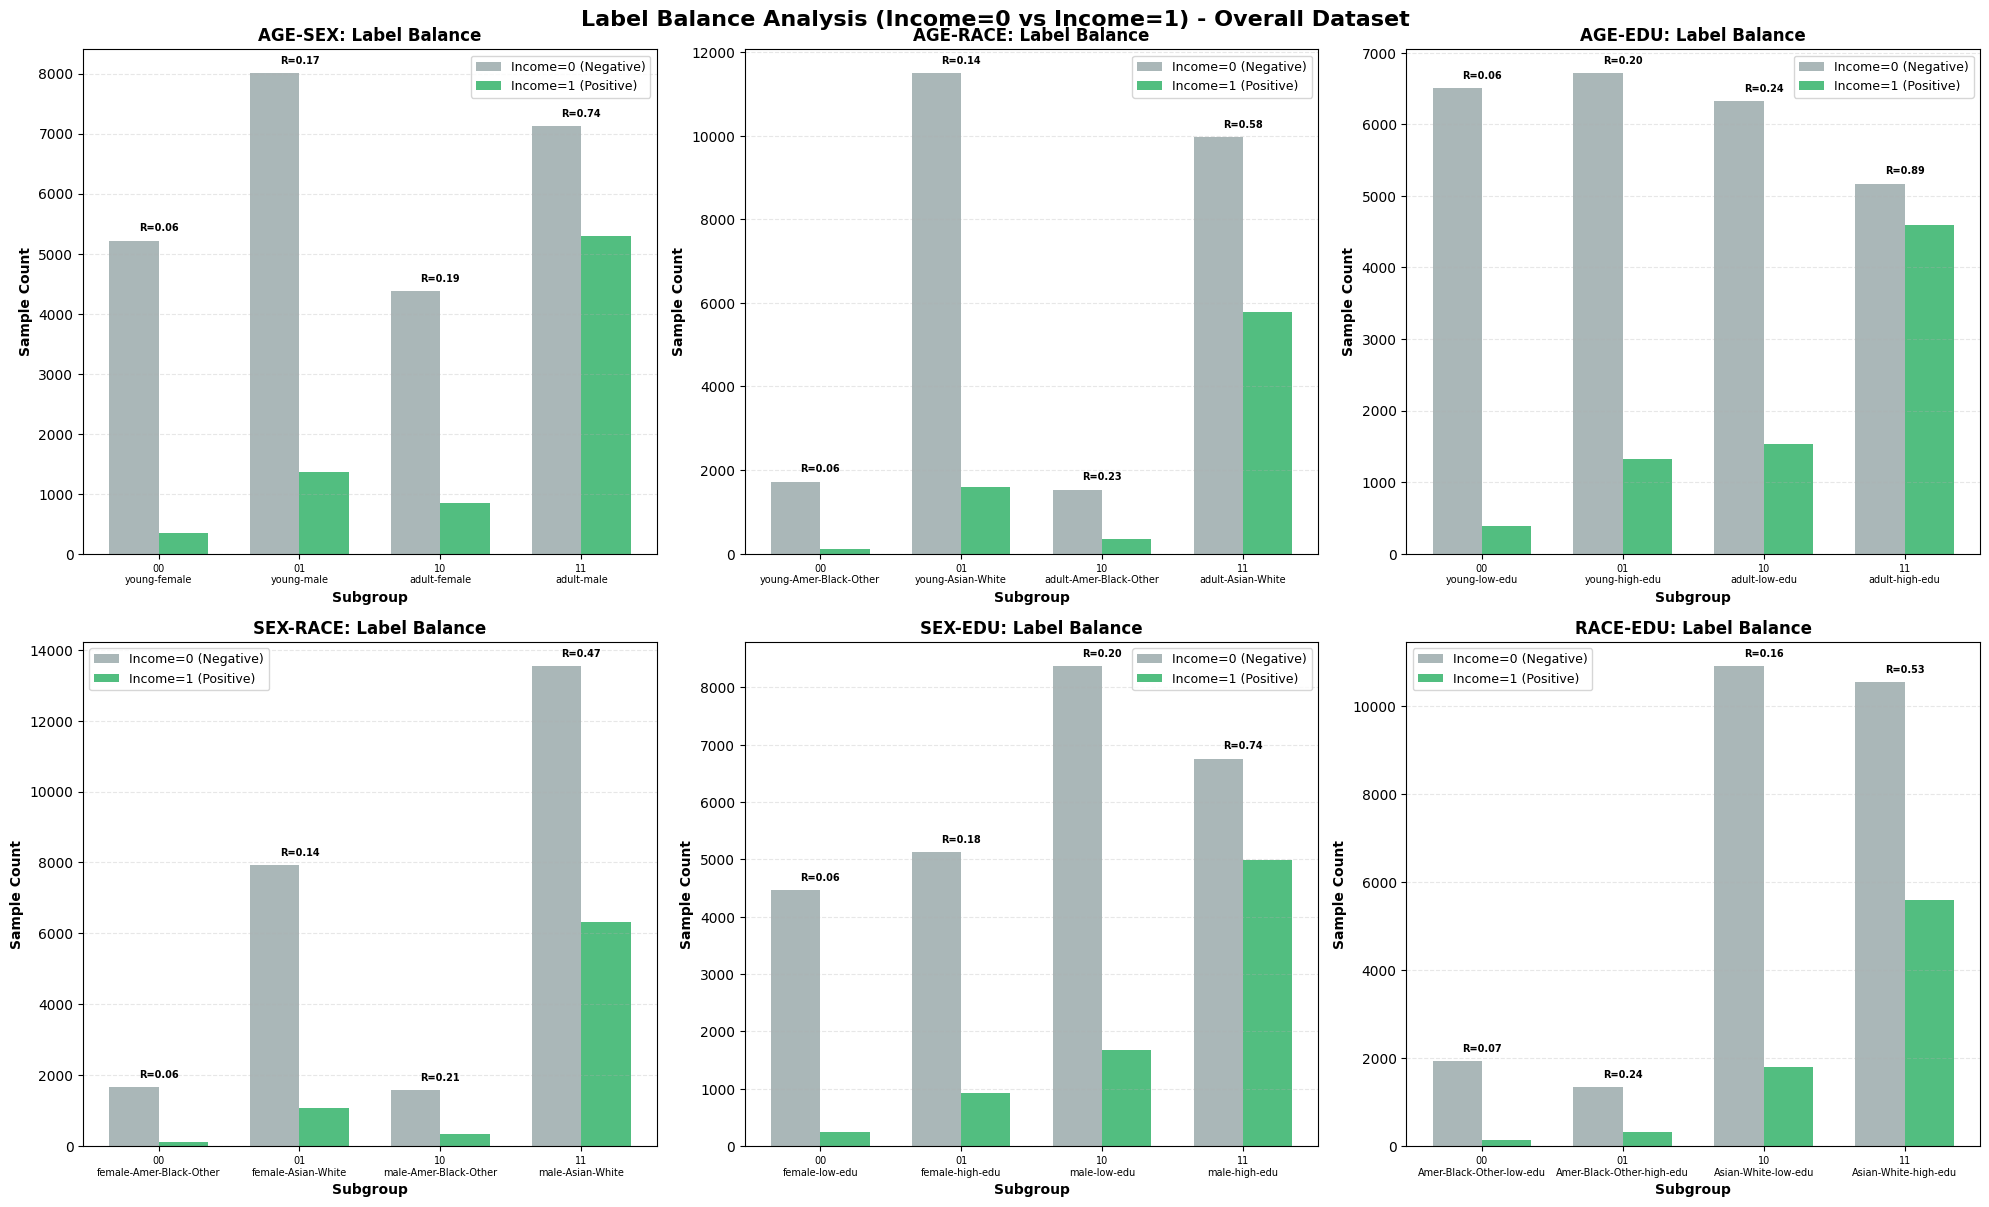

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, combo in enumerate(two_attr_combinations):
    ax = axes[idx]
    attrs = combo.split('-')
    
    # Get data from overall distribution
    label_0 = overall_distribution[combo]['income=0']
    label_1 = overall_distribution[combo]['income=1']
    
    all_subgroups = sorted(set(label_0.index) | set(label_1.index))
    
    neg_counts = [label_0.get(sg, 0) for sg in all_subgroups]
    pos_counts = [label_1.get(sg, 0) for sg in all_subgroups]
    
    # Decode labels
    decoded_labels = []
    for sg in all_subgroups:
        decoded = '-'.join([mapping[attrs[i]][int(sg[i])] for i in range(len(attrs))])
        decoded_labels.append(f"{sg}\n{decoded}")
    
    x = np.arange(len(all_subgroups))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, neg_counts, width, label='Income=0 (Negative)', alpha=0.8, color='#95a5a6')
    bars2 = ax.bar(x + width/2, pos_counts, width, label='Income=1 (Positive)', alpha=0.8, color='#27ae60')
    
    # Add value labels and ratio
    for i, sg in enumerate(all_subgroups):
        neg = neg_counts[i]
        pos = pos_counts[i]
        ratio = pos / neg if neg > 0 else 0
        
        # Show ratio above bars
        max_height = max(neg, pos)
        ax.text(x[i], max_height + max(neg_counts + pos_counts) * 0.02, 
               f'R={ratio:.2f}', ha='center', fontsize=7, fontweight='bold')
    
    ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
    ax.set_ylabel('Sample Count', fontsize=10, fontweight='bold')
    ax.set_title(f'{combo.upper()}: Label Balance', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(decoded_labels, fontsize=7)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.suptitle('Label Balance Analysis (Income=0 vs Income=1) - Overall Dataset', 
            fontsize=16, fontweight='bold', y=1.002)
plt.show()

---

### Utilities

In [ ]:
# PPE
# for i in np.arange(10):
#     print(f"------- LAMBDA: {i} ---------")
#     weights_notsized = compute_weights_notsized(float(i), 'PPE')
#     compute_penalties_after_reweighting(weights_notsized, 'PPE')  # Explicitly pass metric

In [ ]:
# FPN
# for i in np.arange(10):
#     print(f"------- LAMBDA: {i} ---------")
#     weights_notsized = compute_weights_notsized(float(i), 'FPN')
#     compute_penalties_after_reweighting(weights_notsized, 'FPN')  # Explicitly pass metric

In [ ]:
"""
XXX age-sex
00: [[805, 9], [28, 21]]
10: [[632, 22], [65, 67]]
11: [[849, 225], [213, 570]]
01: [[1118, 29], [151, 80]]

NO age-race
00: [[228, 0], [10, 5]]
01: [[1694, 39], [172, 93]]
10: [[241, 9], [30, 21]]
11: [[1238, 240], [250, 614]]

XXX age-edu
00: [[938, 8], [55, 16]]
01: [[987, 28], [125, 84]]
10: [[943, 17], [163, 63]]
11: [[539, 229], [115, 574]]

NO sex-race
00: [[232, 2], [6, 6]]
01: [[1204, 30], [87, 82]]
10: [[236, 8], [30, 24]]
11: [[1732, 245], [333, 627]]

XXX sex-edu
00: [[672, 7], [36, 10]]
01: [[765, 24], [58, 77]]
10: [[1206, 21], [181, 70]]
11: [[759, 235], [184, 579]]

NO race-edu
00: [[279, 2], [15, 8]]
01: [[190, 7], [24, 19]]
10: [[1598, 27], [203, 71]]
11: [[1334, 252], [218, 637]]

"""